In [5]:
"""
Parameters
"""
# Set this to agree with `UNGDC-DataPrep.ipynb`
data_path = "./output_data/UN-2026-03-02-Additional"

input_parquet = 'input-data/UNGDC-demo-30pc-dataset.pq'

decimate = False
decimation_factor = 3
## Mapper settings
import temporalmapper as tm

import pandas as pd
import numpy as np
from tqdm import tqdm
from pathlib import Path
from tqdm.auto import tqdm

# Import the pre-processed dataset (see: UNGDC-DataPrep.ipynb)
df = pd.read_parquet(input_parquet)

embedding_vectors = df['embedding'].to_numpy()
reduced_vectors = df['reduced'].to_numpy()
text = df['chunk'].to_numpy()
time = df['year'].to_numpy()

rng = np.random.default_rng()
if decimate:
    choice_index = rng.choice(len(df), size=len(df)//decimation_factor, replace=False)
    embedding_vectors = embedding_vectors[choice_index]
    reduced_vectors = reduced_vectors[choice_index]
    text = text[choice_index]
    time = time[choice_index]

# Sort all arrays by time
sorted_idx = np.argsort(time)
time = time[sorted_idx]
text = text[sorted_idx]
reduced_vectors = np.vstack(reduced_vectors[sorted_idx])
embedding_vectors = np.vstack(embedding_vectors[sorted_idx])
reduced_vectors_with_time = np.hstack([reduced_vectors, time.reshape(-1,1)])

In [22]:
import networkx as nx
from fast_hdbscan import HDBSCAN
def contract(G):
    for node in list(G.nodes()):
        if G.degree(node) == 2:
            edges = list(G.edges(node))
            G.add_edge(edges[0][1], edges[1][1])
            G.remove_node(node)
    return G

kerneled_contracted = {}
contracted = {}
list_of_stats = []

mapper_params = {
    "neighbours": 500,
    "slice_method": "data",
    "overlap":0.5,
    "kernel":tm.kernels.square,
    "clusterer":HDBSCAN(min_cluster_size=100)
}
N_range = range(6,15)

for N in tqdm(N_range):
    for b in {True, False}:
        mapper_params['N_checkpoints'] = N
        mapper_params['density_based'] = b
        mapper = tm.TemporalMapper(**mapper_params)
        mapper.fit(reduced_vectors_with_time)
        G = mapper.G.to_undirected()
        props = {
            'kerneled':mapper.density_based,
            'N':mapper.N_checkpoints,
            'g':mapper.overlap,
            'k':mapper.neighbours,
        }
        props['components'] = nx.number_connected_components(G)
        props['isolates'] = nx.number_of_isolates(G)
        props['average_degree'] = np.mean([G.degree(node) for node in G.nodes()])
        if mapper.density_based:
            kerneled_contracted[mapper.N_checkpoints]=contract(G)
        else:
            contracted[mapper.N_checkpoints]=contract(G)
        
        list_of_stats.append(props)


graph_stats = pd.DataFrame(list_of_stats) 
graph_stats.head()

  0%|          | 0/9 [00:00<?, ?it/s]

,kerneled,N,g,k,components,isolates,average_degree
0,False,6,0.5,500,49,22,1.450292
1,True,6,0.5,500,64,28,1.555556
2,False,7,0.5,500,46,21,1.578378
3,True,7,0.5,500,55,23,1.624000
4,False,8,0.5,500,43,15,1.606061


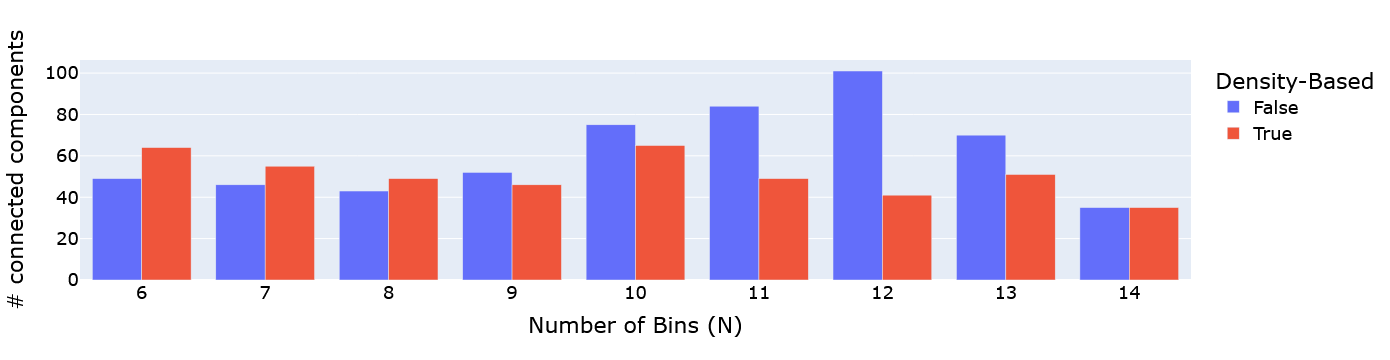

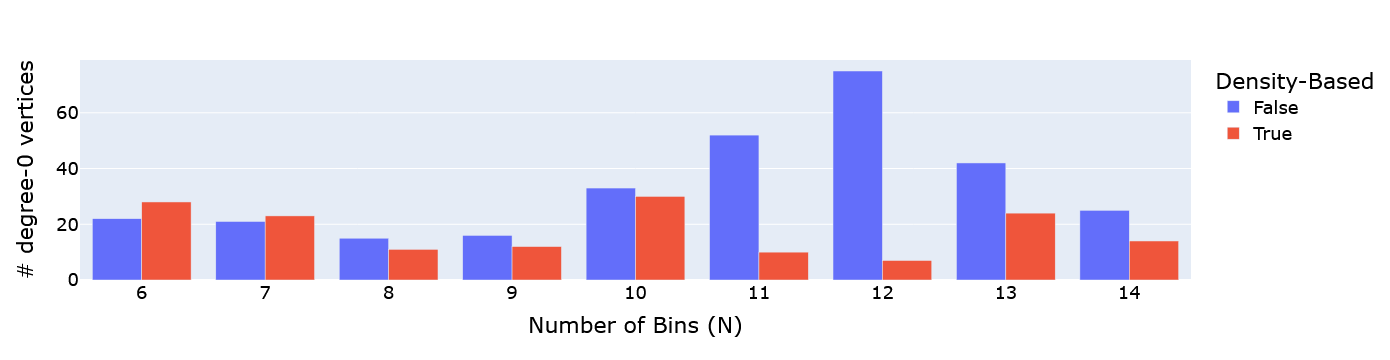

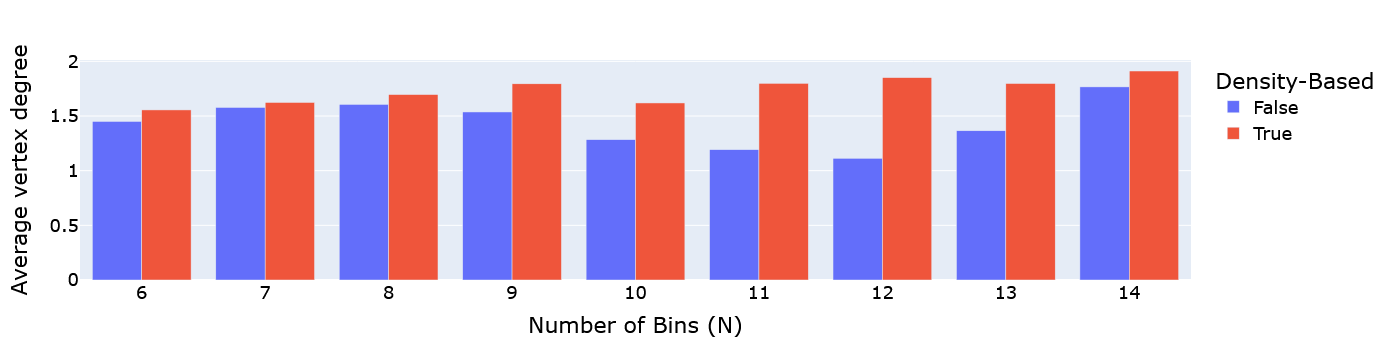

In [26]:
import plotly.express as px
import pandas as pd
graph_stats = pd.DataFrame(list_of_stats) 

fig = px.bar(
    graph_stats,
    x='N',
    y='components',
    color="kerneled",
    barmode="group",
     labels={
         "N":"Number of Bins (N)",
         "components":"# connected components",
         "kerneled": "Density-Based"
 }
)
fig.update_layout(
    font=dict(size=18, color="Black")
)
fig.show()
fig = px.bar(
    graph_stats,
    x='N',
    y='isolates',
    color="kerneled",
    barmode="group",
     labels={
         "N":"Number of Bins (N)",
         "isolates":"# degree-0 vertices",
         "kerneled": "Density-Based"
 }
)
fig.update_layout(
    font=dict(size=18, color="Black")
)
fig.show()
fig = px.bar(
    graph_stats,
    x='N',
    y='average_degree',
    color="kerneled",
    barmode="group",
     labels={
         "N":"Number of Bins (N)",
         "average_degree":"Average vertex degree",
         "kerneled": "Density-Based"
 }
)
fig.update_layout(
    font=dict(size=18, color="Black")
)
fig.show()